# ARIMA(p,d,q) 살펴보기
비정상적 시계열 예측  

---  
MA, AR, ARMA: 모두 **정상적** 시계열에만 사용 가능. 그래서 주로 차분과 같은 변환을 적용하고, ADF 테스트를 적용해 정상성을 테스트해야 한다. 그리고 예측 모델은 모두 차분된 값을 반환했기에 원래 데이터 규모로 값을 돌리려면 역변환해야 함.  

--- 
이제는 **비정상적 시계열**을 예측할 수 있도록 ARMA(p,q) 모델에 다른 구성요소를 추가.  
ARIMA(p,d,q) (AutoRegressive Integrated Moving Average): 자기회귀누적이동평균  
Integration Order (적분 차수)
- d 로 표시
- 비정상적 시계열을 **직접** 모델링 할 수 있어 차분하고 역변환하는 단계 건너뛸 수 있음.  

ARIMA(p,d,q) 모델과 적분 차수 d를 정의하고, 일반적 모델링 절차에 한 단계를 추가.
- 그 다음, 수정된 절차를 적용해 비정상적 시계열, 즉 추세가 있는 시계열 혹은 시간에 따른 분산이 일정하지 않은 시계열 데이터를 예측.

# 7.1 자기회귀누적이동평균과정 모델 정의
AR(p), I(d), MA(q) 조합.  

---
ARMA와 마찬가지로 ARIMA는 현잿값이 AR(p) 부분에서 나오는 과것값과 MA(q) 부분에서 나오는 과거 오차에 따라 달라진다.  
**하지만** ARIMA는 $y_t$로 표시되는 <u>원본 수열</u>을 사용하는 대신 $y'_t$로 표시되는 **차분된 수열**을 사용.$y'_t$는 한 번 이상 차분된 수열을 나타낼 수 있다는 점에 주의.  

ARIMA(p,d,q):  
$y'_t = C+\phi_1y'_{t-1}+...+\phi_py'_{t-p}+\theta_1\epsilon'_{t-1}+...+\theta_q\epsilon'_{t-q}+\epsilon_t$  
- $y'_t$: 차분된 수열의 현잿값
- $C$: 상수
- $\phi_py'_{t-p}$: 차분된 수열의 과것값
- $\mu$: 차분된 수열의 평균
- $\theta_q\epsilon_{t-q}$: 과거 오차 항
- $\epsilon_t$: 현재 오차 항

ARMA와 마찬가지로 p는 모델에 포함할 시계열 중 지연된 값의 개수 결정, q는 모델에 포함하는 지연된 오차 항의 개수를 결정.  
d는 적분 차수. 수열을 정상적으로 만들기 위해 차분한 횟수.
- 수열을 한 번 차분해서 정상적이게 되면 d = 1; 두 번 차분했으면 d = 2
- 차분을 적용하면 정상적으로 만들 수 있는 시계열: 적분된 수열(integrated series).
- 비정상적 적분 시계열인 경우, ARIMA(p,d,q) 모델을 사용해 예측 수행 가능. 

---
ARIMA는 비정상적 시계열에 적용할 수 있는 ARMA 모델.

# 7.2 비정상적 시계열에 적용하기 위해 일반적 모델링 절차 수정하기
대부분 시계열이 정상적이 되기 위해 두 번 이상 차분해야 하는 경우는 드물었음.  

시계열에 변환을 적용할 때 d의 값을 시계열의 차분 횟수로 설정하는 단계 추가. 그 다음 ARMA(p,q) 모델을 피팅하는 대신 많은 ARIMA(p,d,q) 모델을 피팅. 나머지는 ARMA와 동일한 절차 적용, AIC를 통해 최적의 모델 선택 후 잔차 분석.  

d = 0인 경우 ARMA(p,q)와 동일하다. 

![alt text](Screenshots/7.4.png)

# 7.3 비정상적 시계열 예측 
일반적 모델링 절차를 적용해 J&J *분기별* 주당순이익을 예측. 1년간의 분기별 주당순이익을 예측. 1년은 4분기가 있기에 향후 4번의 시간 단계를 예측. 데이터 집합은 1960-1980년. 

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/jj.csv')

df

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02


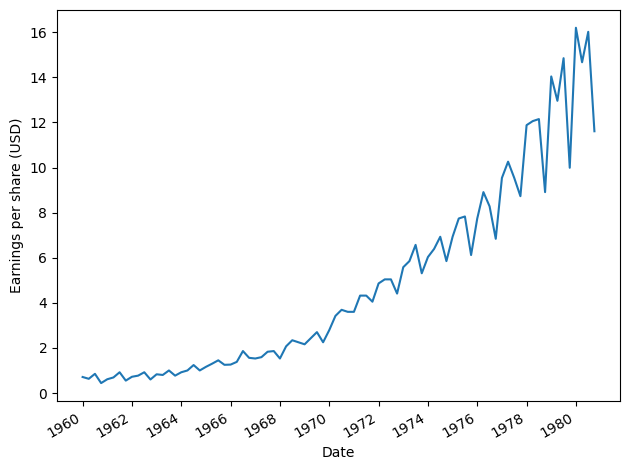

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel("Date")
ax.set_ylabel('Earnings per share (USD)')

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

증가하는 경향이 있으니 긍정적인 추세. 그럼에도 부룩하고 ADF 테스트를 적용하여 데이터가 정상적인가 확인.

In [4]:
from statsmodels.tsa.stattools import adfuller

ad_fuller_result = adfuller(df['data'])

print(f"ADF Stats: {ad_fuller_result[0]}")
print(f"ADF p-val: {ad_fuller_result[1]}")

ADF Stats: 2.742016573457475
ADF p-val: 1.0


ADF 통계 2.74: 큰 음수가 아님  
p-val: 0.05보다 크므로 귀무가설을 기각할 수 없음 --> 수열이 비정상적이라는 뜻.  

그럼 이제 정상적으로 되려면 몇분 차분해야 하는가? 

In [5]:
eps_diff = np.diff(df['data'], n=1) #1차 차분 적용

ad_fuller_result = adfuller(eps_diff)

print(f"ADF Stats: {ad_fuller_result[0]}")
print(f"ADF p-val: {ad_fuller_result[1]}")

ADF Stats: -0.40740976363803183
ADF p-val: 0.9088542416911329


ADF Stats -0.41: 큰 음수가 아님  
p-val: 0.05보다 아직 큼 --> 귀무가설 기각할 수 없음.

1차 차분 후에도 수열이 정상적이지 않음. 다시 한 번 더.

In [6]:
eps_diff2 = np.diff(eps_diff, n=1)

ad_fuller_result = adfuller(eps_diff2)

print(f"ADF Stats: {ad_fuller_result[0]}")
print(f"ADF p-val: {ad_fuller_result[1]}")

ADF Stats: -3.5851628747931596
ADF p-val: 0.006051099869603575


이제 ADF 통계는 큰 음수이고,  
p-val은 0.05보다 작음 --> 시계열 정상적.  

두 번 차분했으니 d = 2.

모델 피팅 전, 데이터를 훈련 집합과 테스트 집합으로 분리해야 함.
- 테스트: 마지막 1년간의 데이터 (1980년)
- 트레이닝: 1960-1979년

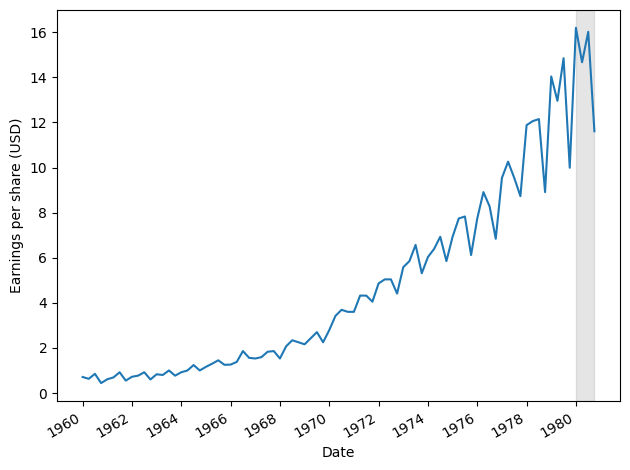

In [7]:
fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# optimize_ARIMA 함수 정의. 

from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

#함수: 각 (p,q)조합과 그에 해당하는 AIC를 저장할 빈 목록을 초기화. 그 다음 각 (p,q) 조합에 대한 ARMA(p,q)모델을 데이터 피팅.
# AIC 계산하고 그 결과 저장. 그 다음 DataFrame을 생성하고, AIC 값이 낮을수록 더 좋은 모델이므로 AIC 값을 기준으로 오름차순으로 정렬.
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame: #endog: 관측된 시계열 데이터
    # 고유 (p,q) 조합들의 목록, 적분 차수 d를 입력받는다. 
    results = [] 

    for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.
        try:
            model = SARIMAX(endog, order = (order[0], d, order[1]),
                            simple_differencing=False).fit(disp = False) #SARIMAX 함수를 사용해 ARMA(p,d,q) 모델 피팅. 
                            #차분이 되지 않도록 simple_differencing을 False.
                            # 콘솔에 상태 메시지 안 나오도록 disp = False.
        except:
            continue

        aic = model.aic #모델의 aic 계산.
        results.append([order,aic]) #결과 목록에 (p,q) 조합과 AIC를 튜플로 추가.

    result_df = pd.DataFrame(results) #(p,q) 조합과 AIC를 DataFrame에 저장
    result_df.columns = ['(p,q)', 'AIC'] #DataFrame의 열에 레이블 지정

    # ascending order as lower AIC is better
    result_df = result_df.sort_values(by = 'AIC', ascending = True).reset_index(drop = True) #AIC값을 기준으로 오름차순 정렬.

    return result_df